In [1]:
# import libraries
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.graphics.gofplots import qqplot
from statsmodels.tsa.stattools import adfuller

from tqdm import tqdm_notebook
from itertools import product
from typing import Union

import matplotlib.pyplot as plt
import statsmodels.api as sm
import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

In [2]:
# read in data
df = pd.read_csv('../datasets/TX-Data/met-cleanedup/met_data1_cleaned.csv', sep=",", parse_dates=["Date"], index_col="Date")

In [104]:
# Slice data to isolate 2015-2020
df = df[(df.index > "2014-12-31 23:00") & (df.index < "2020-12-31 23:00")]

In [4]:
# Replace inf values and Fill nan values
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.fillna(df.mean(), inplace=True)

df

,Ppt,Tair,RH,Windspeed,Winddirection,Srad
Date,,,,,,
2015-01-01 00:00:00,0.0,-1.090,81.5,1.052,52.27,0.63
2015-01-01 01:00:00,0.0,-1.038,81.7,0.959,46.71,0.62
2015-01-01 02:00:00,0.0,-0.981,82.0,1.062,52.04,0.60
2015-01-01 03:00:00,0.0,-0.814,81.9,0.887,58.91,0.64
2015-01-01 04:00:00,0.0,-0.805,90.0,0.828,16.55,0.20
...,...,...,...,...,...,...
2020-12-31 18:00:00,0.0,-0.342,100.0,2.707,8.87,6.77
2020-12-31 19:00:00,0.0,-0.490,100.0,2.086,43.56,0.00
2020-12-31 20:00:00,0.0,-0.869,100.0,2.828,28.17,0.10


In [5]:
# Reseample with monthly mean
df = df.resample('M').mean()

In [6]:
# removes spaces in the column names
def remove_spaces(df):
    df.columns = df.columns.str.replace(' ','')
    df['Ppt'] = df['Ppt'].astype(float)
    df['Tair'] = df['Tair'].astype(float)
    df['RH'] = df['RH'].astype(float)
    df['Windspeed'] = df['Windspeed'].astype(float)
    df['Winddirection'] = df['Winddirection'].astype(float)
    df['Srad'] = df['Srad'].astype(float)  

In [7]:
# remove column name spaces of each DataFrame 
remove_spaces(df)

In [8]:
# view head of data frame
df.head(10)

,Ppt,Tair,RH,Windspeed,Winddirection,Srad
Date,,,,,,
2015-01-31,0.072035,7.939099,67.428589,1.547981,125.413544,113.610780
2015-02-28,0.006426,9.028917,70.650015,2.025886,141.317670,140.054435
2015-03-31,0.077839,13.585753,76.834435,1.663655,143.476980,174.070484
2015-04-30,0.081847,19.223819,73.753208,2.031969,164.605403,206.481750
2015-05-31,0.294976,21.663794,81.306694,2.194745,165.946011,195.665538
2015-06-30,0.078669,24.947047,74.396847,1.750765,183.299560,277.447944
2015-07-31,0.037898,27.372552,63.137110,2.276917,188.493058,312.588132
2015-08-31,0.001366,28.382122,55.145027,1.689995,178.802012,277.001452
2015-09-30,0.011994,25.864828,58.636056,1.558166,164.779677,236.575625


In [9]:
# Verify shape of data frame
df.shape

(72, 6)

## Visualization 

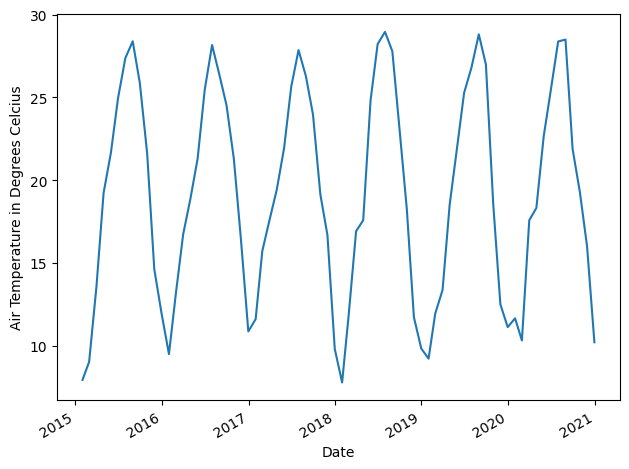

In [10]:
# Visualize Tair Montly Data for 2015
fig, ax = plt.subplots()

ax.plot(df.Tair)
ax.set_xlabel('Date')
ax.set_ylabel('Air Temperature in Degrees Celcius')


fig.autofmt_xdate()
plt.tight_layout()



## Exploration 

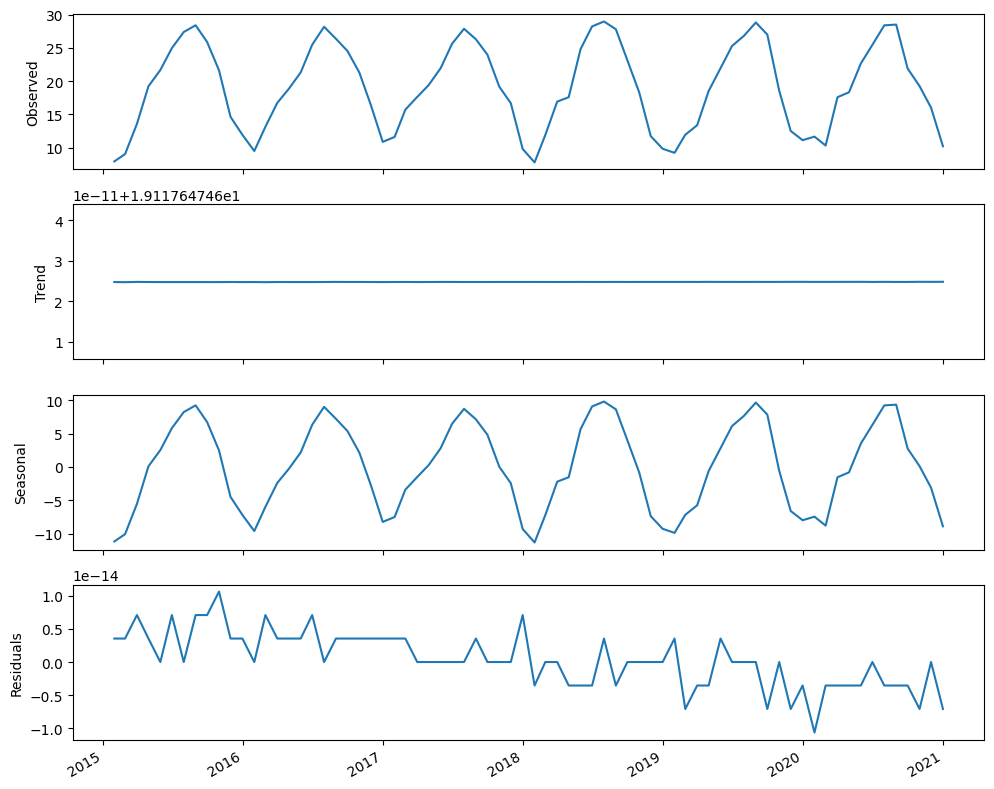

In [45]:
# Decompose data  to view seasonality, trend, and residuals
decomposition = STL(df.Tair, period=72).fit()

fig, (ax1, ax2, ax3, ax4) = plt.subplots(nrows=4, ncols=1, sharex=True, figsize=(10,8))

ax1.plot(decomposition.observed)
ax1.set_ylabel('Observed')

ax2.plot(decomposition.trend)
ax2.set_ylabel('Trend')

ax3.plot(decomposition.seasonal)
ax3.set_ylabel('Seasonal')

ax4.plot(decomposition.resid)
ax4.set_ylabel('Residuals')


fig.autofmt_xdate()
plt.tight_layout()



## Modeling 

In [46]:
# Preform Ad Fuller Test to check for stationarity
ad_fuller_result = adfuller(df.Tair)

print(f'ADF Statistic: {ad_fuller_result[0]}')
print(f'p-value: {ad_fuller_result[1]}')

ADF Statistic: -2.2075671090695734
p-value: 0.2035105054720045


In [47]:
# Difference Data and check Ad Fuller test again
Tair_diff = np.diff(df.Tair, n=1)

ad_fuller_result = adfuller(Tair_diff)

print(f'ADF Statistic: {ad_fuller_result[0]}')
print(f'p-value: {ad_fuller_result[1]}')

ADF Statistic: -5.607389833105308
p-value: 1.2253741488076154e-06


In [48]:
# Tair_diff_seasonal_diff = np.diff(Tair_diff, n=12)

# ad_fuller_result = adfuller(Tair_diff_seasonal_diff)

# print(f'ADF Statistic: {ad_fuller_result[0]}')
# print(f'p-value: {ad_fuller_result[1]}')

### Train/test split 

In [49]:
# split data into train and test
train_len = 60
test_len = 12
total_len = 72

train = df.Tair[:train_len]
test = df.Tair[train_len:]

test

Date
2020-01-31    11.656753
2020-02-29    10.319754
2020-03-31    17.578294
2020-04-30    18.320365
2020-05-31    22.651471
2020-06-30    25.441318
2020-07-31    28.373371
2020-08-31    28.487495
2020-09-30    21.878556
2020-10-31    19.245132
2020-11-30    16.005576
2020-12-31    10.208196
Freq: M, Name: Tair, dtype: float64

### SARIMA(p,0,q)(P,0,Q)<sub>12<sub> 

In [50]:
# Define SARIMA model
from typing import Union
from tqdm import tqdm_notebook
from statsmodels.tsa.statespace.sarimax import SARIMAX

def optimize_SARIMAX(endog: Union[pd.Series, list], exog: Union[pd.Series, list], order_list: list, d: int, D: int, s: int) -> pd.DataFrame:
    
    results = []
    
    for order in tqdm_notebook(order_list):
        try: 
            model = SARIMAX(
                endog,
                exog,
                order=(order[0], d, order[1]),
                seasonal_order=(order[2], D, order[3], s),
                simple_differencing=False).fit(disp=False)
        except:
            continue
            
        aic = model.aic
        print([order, aic])
        results.append([order, model.aic])
        
    result_df = pd.DataFrame(results)
    result_df.columns = ['(p,q,P,Q)', 'AIC']
    
    #Sort in ascending order, lower AIC is better
    result_df = result_df.sort_values(by='AIC', ascending=True).reset_index(drop=True)
    
    return result_df

In [51]:
# Define range of parameter's to check
ps = range(0, 2, 1)
qs = range(0, 2, 1)
Ps = range(0, 2, 1)
Qs = range(0, 2, 1)

order_list = list(product(ps, qs, Ps, Qs))

d = 0
D = 0
s = 12

In [52]:
# Find best set of parameters using the AIC
SARIMA_result_df = optimize_SARIMAX(train, None, order_list, d, D, s)
SARIMA_result_df

  0%|          | 0/16 [00:00<?, ?it/s]

[(0, 0, 0, 0), 532.8657726402786]
[(0, 0, 0, 1), 484.40463544657615]
[(0, 0, 1, 0), 312.66677460874183]
[(0, 0, 1, 1), 310.2644899195353]
[(0, 1, 0, 0), 458.6443583552001]
[(0, 1, 0, 1), 413.8680042408664]
[(0, 1, 1, 0), 300.21352876648217]
[(0, 1, 1, 1), 333.8354461029828]
[(1, 0, 0, 0), 333.5996243852599]
[(1, 0, 0, 1), 307.44724806351144]
[(1, 0, 1, 0), 281.66409005280934]
[(1, 0, 1, 1), 274.9795316743223]
[(1, 1, 0, 0), 309.86724843670476]
[(1, 1, 0, 1), 300.064896592369]
[(1, 1, 1, 0), 283.5772270537988]
[(1, 1, 1, 1), 276.955668575248]


,"(p,q,P,Q)",AIC
0,"(1, 0, 1, 1)",274.979532
1,"(1, 1, 1, 1)",276.955669
2,"(1, 0, 1, 0)",281.664090
3,"(1, 1, 1, 0)",283.577227
4,"(1, 1, 0, 1)",300.064897
5,"(0, 1, 1, 0)",300.213529
6,"(1, 0, 0, 1)",307.447248
7,"(1, 1, 0, 0)",309.867248
8,"(0, 0, 1, 1)",310.264490
9,"(0, 0, 1, 0)",312.666775


In [53]:
# Define and fit SARIMAX model
SARIMA_model = SARIMAX(train, order=((SARIMA_result_df.iloc[0][0][0]), 0, SARIMA_result_df.iloc[0][0][1]), seasonal_order = (SARIMA_result_df.iloc[0][0][2], 0, SARIMA_result_df.iloc[0][0][3], total_len), simple_differencing=False, enforce_stationarity=False)
SARIMA_model_fit = SARIMA_model.fit(disp=False)

print(SARIMA_model_fit.summary())

                                      SARIMAX Results                                       
Dep. Variable:                                 Tair   No. Observations:                   60
Model:             SARIMAX(1, 0, 0)x(1, 0, [1], 72)   Log Likelihood                   0.000
Date:                              Sun, 02 Jul 2023   AIC                              8.000
Time:                                      11:08:06   BIC                                nan
Sample:                                  01-31-2015   HQIC                               nan
                                       - 12-31-2019                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9845         -0       -inf      0.000       0.985       0.985
ar.S.L72           

In [54]:
# Plot diagnostics
SARIMA_model_fit.plot_diagnostics(figsize=(10,8));

ValueError: Length of endogenous variable must be larger the the number of lags used in the model and the number of observations burned in the log-likelihood calculation.

<Figure size 1000x800 with 0 Axes>

In [55]:
# Check values have appropriate autocorellation
residuals = SARIMA_model_fit.resid

lbvalue, pvalue = acorr_ljungbox(residuals, np.arange(1, 11, 1))

print(pvalue)

lb_pvalue


## Forecasting 

In [97]:
def rolling_forecast(df: pd.DataFrame, train_len: int, horizon: int, window: int, method: str) -> list:
    
    total_len = train_len + horizon
    end_idx = train_len
    
    
    if method == 'last_season':
        pred_last_season = []
        
        
        for i in range(train_len, total_len, window):
            last_season = df.Tair[i-window:i]
            pred_last_season.extend(last_season)
            
        return pred_last_season
    
    elif method == 'SARIMA':
        pred_SARIMA = []
        
        for i in range(train_len, total_len, window):
            model = SARIMAX(df.Tair[:i], order=(SARIMA_result_df.iloc[0][0][0], 0, SARIMA_result_df.iloc[0][0][1]), seasonal_order = (SARIMA_result_df.iloc[0][0][2], 0, SARIMA_result_df.iloc[0][0][3], 12), simple_differencing=False)
            res = model.fit(disp=False)
            predictions = res.get_prediction(0, i + window - 1)
            oos_pred = predictions.predicted_mean[-window:]
            pred_SARIMA.extend(oos_pred)
            
        return pred_SARIMA

In [98]:
pred_df = df[train_len:]

pred_df

,Ppt,Tair,RH,Windspeed,Winddirection,Srad
Date,,,,,,
2020-01-31,0.074763,11.656753,70.678777,1.769515,172.654038,117.010901
2020-02-29,0.051457,10.319754,71.040733,1.930824,146.350635,144.192227
2020-03-31,0.105487,17.578294,78.742460,1.945194,165.829680,147.392204
2020-04-30,0.114303,18.320365,70.896958,1.778060,154.481067,220.948694
2020-05-31,0.209957,22.651471,70.565860,1.869281,163.343905,267.534691
2020-06-30,0.020461,25.441318,68.773917,1.892700,172.586390,288.940472
2020-07-31,0.012632,28.373371,63.380806,1.911068,179.631645,289.584073
2020-08-31,0.009218,28.487495,56.992675,1.669391,175.461543,278.116263
2020-09-30,0.198264,21.878556,78.318292,1.358595,135.840933,180.323375


In [99]:
# Define rolling forcast structure and create baseline for model by recalling the previous season
TRAIN_LEN = train_len
HORIZON = test_len
WINDOW = int(test_len / 3)

pred_df['last_season'] = rolling_forecast(df, TRAIN_LEN, HORIZON, WINDOW, 'last_season')
pred_df.last_season

Date
2020-01-31    26.984912
2020-02-29    18.538910
2020-03-31    12.506118
2020-04-30    11.124320
2020-05-31    11.656753
2020-06-30    10.319754
2020-07-31    17.578294
2020-08-31    18.320365
2020-09-30    22.651471
2020-10-31    25.441318
2020-11-30    28.373371
2020-12-31    28.487495
Freq: M, Name: last_season, dtype: float64

In [100]:
# Define SARIMA Prediction Dataframe
pred_df['SARIMA'] = rolling_forecast(df, TRAIN_LEN, HORIZON, WINDOW, 'SARIMA')

pred_df.SARIMA

Date
2020-01-31     9.938503
2020-02-29    12.846638
2020-03-31    15.888662
2020-04-30    18.744334
2020-05-31    21.750134
2020-06-30    25.101631
2020-07-31    26.857759
2020-08-31    26.537712
2020-09-30    25.696559
2020-10-31    20.460686
2020-11-30    15.060537
2020-12-31    11.384793
Freq: M, Name: SARIMA, dtype: float64

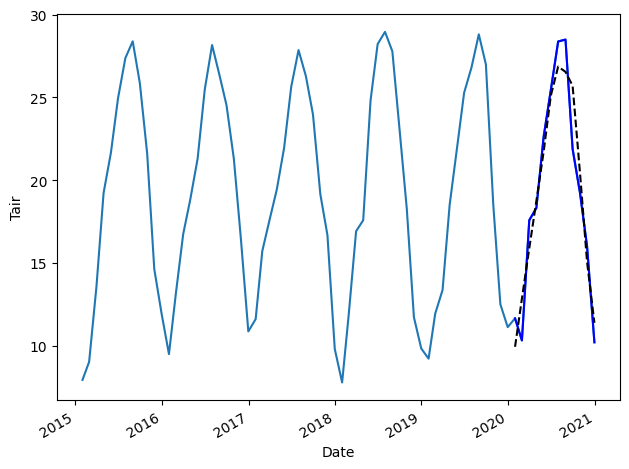

In [101]:
# visualize predictions
fig, ax = plt.subplots()

ax.plot(df.Tair)
ax.plot(pred_df.Tair, 'b-', label='actual')
# ax.plot(pred_df.last_season, 'r:', label='naive seasonal')
ax.plot(pred_df.SARIMA, 'k--', label='SARIMA')
ax.set_xlabel('Date')
ax.set_ylabel('Tair')

fig.autofmt_xdate()
plt.tight_layout()



## Evaluate 

In [103]:
mse=np.mean((pred_df.Tair-pred_df.SARIMA)**2)
mse

3.1442386112781224